# Import the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import mean_squared_error, r2_score


# Load the Dataset

In [2]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

feature_names = housing.feature_names

# Train and Test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.8)
}

# Train and Evaluate

In [17]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mse, r2])

    print(f"\n{name}")
    print("-" * 40)

    print("MSE :", mse)
    print("R2 Score :", r2)

    # Show coefficients
    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model.coef_
    })

    print("\nCoefficients:")
    print(coef_df)



Linear Regression
----------------------------------------
MSE : 0.5558915986952442
R2 Score : 0.575787706032451

Coefficients:
      Feature  Coefficient
0      MedInc     0.854383
1    HouseAge     0.122546
2    AveRooms    -0.294410
3   AveBedrms     0.339259
4  Population    -0.002308
5    AveOccup    -0.040829
6    Latitude    -0.896929
7   Longitude    -0.869842

Ridge
----------------------------------------
MSE : 0.5558548589435974
R2 Score : 0.575815742891368

Coefficients:
      Feature  Coefficient
0      MedInc     0.854327
1    HouseAge     0.122624
2    AveRooms    -0.294210
3   AveBedrms     0.339008
4  Population    -0.002282
5    AveOccup    -0.040833
6    Latitude    -0.896168
7   Longitude    -0.869071

Lasso
----------------------------------------
MSE : 0.6796290284328821
R2 Score : 0.4813611325029077

Coefficients:
      Feature  Coefficient
0      MedInc     0.710598
1    HouseAge     0.106453
2    AveRooms    -0.000000
3   AveBedrms     0.000000
4  Population  

# Final Comparison

In [11]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MSE", "R2 Score"]
)

print("\nFinal Comparison")
print(results_df)


Final Comparison
               Model       MSE  R2 Score
0  Linear Regression  0.555892  0.575788
1              Ridge  0.555855  0.575816
2              Lasso  0.679629  0.481361
3        Elastic Net  0.668665  0.489728


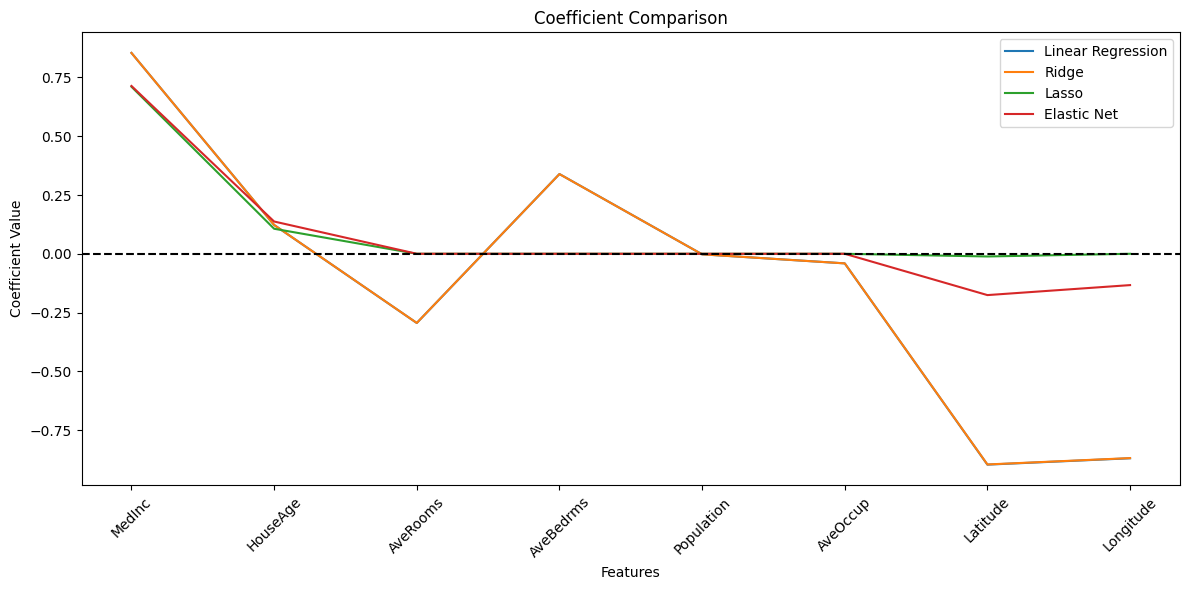

In [8]:
plt.figure(figsize=(12, 6))

for name, model in models.items():
    plt.plot(model.coef_, label=name)

plt.xticks(
    range(len(feature_names)),
    feature_names,
    rotation=45
)

plt.axhline(y=0, color='black', linestyle='--')

plt.title("Coefficient Comparison")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")

plt.legend()

plt.tight_layout()
plt.show()